<a href="https://colab.research.google.com/github/shoukk8-afk/Architecture-of-Diffusion-by-PyTorch/blob/main/MNIST_Diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode
from torch.utils.data import DataLoader
from Diffusion.model import Diffusion, UNet
from Diffusion.engine import diffusion_training

In [3]:
transform = transforms.Compose([
    #UNet用に32×32とする
    transforms.Resize(32, interpolation=InterpolationMode.BICUBIC),
    #オーギュメンテーションなしで行う
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) #(-1, 1)にスケーリング
])

val_transform = transforms.Compose([
    transforms.Resize(64, interpolation=InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [4]:
train_dataset = datasets.MNIST(root='/content/', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
test_dataset = datasets.MNIST(root='/content/', train=False, download=True, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.05MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.05MB/s]


In [5]:
#チャネル数、サイズがきちんと32×32になっているか確認
img, _ = train_dataset[0]
img.shape

torch.Size([1, 32, 32])

In [6]:
#GPUに設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
loss_fn = nn.MSELoss()

diffusion = Diffusion(loss_fn, device, 500, 32, 30)
model = UNet(1, diffusion)

optimizer = optim.AdamW(
    model.parameters(),
    lr=2e-4,
    weight_decay=0.01
)

In [7]:
model.to(device)

UNet(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downblock1): DownBlock(
    (residual): ResidualBlock(
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (mlp): Sequential(
        (0): SiLU()
        (1): Linear(in_features=32, out_features=64, bias=True)
      )
      (shortcut): Sequential()
    )
    (conv): Conv2d(64, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
  )
  (downblock2): DownBlock(
    (residual): ResidualBlock(
      (bn1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv1): Conv2d(96, 96, ke

In [8]:
#100エポック回す
loss_train, loss_val = diffusion_training(100, optimizer, model, diffusion, train_loader, test_loader)

Epoch: 1 | Train Loss: 0.149125 | Val Loss: 0.048380
Epoch: 2 | Train Loss: 0.037745 | Val Loss: 0.043921
Epoch: 3 | Train Loss: 0.029244 | Val Loss: 0.040198
Epoch: 4 | Train Loss: 0.025569 | Val Loss: 0.041950
Epoch: 5 | Train Loss: 0.023815 | Val Loss: 0.038040
Epoch: 6 | Train Loss: 0.022422 | Val Loss: 0.041226
Epoch: 7 | Train Loss: 0.021698 | Val Loss: 0.037743
Epoch: 8 | Train Loss: 0.021007 | Val Loss: 0.035222
Epoch: 9 | Train Loss: 0.020482 | Val Loss: 0.038129
Epoch: 10 | Train Loss: 0.020091 | Val Loss: 0.033821
Epoch: 11 | Train Loss: 0.019872 | Val Loss: 0.030053
Epoch: 12 | Train Loss: 0.019567 | Val Loss: 0.036954
Epoch: 13 | Train Loss: 0.019332 | Val Loss: 0.034237
Epoch: 14 | Train Loss: 0.019194 | Val Loss: 0.031831
Epoch: 15 | Train Loss: 0.018908 | Val Loss: 0.040884
Epoch: 16 | Train Loss: 0.018850 | Val Loss: 0.036373
Epoch: 17 | Train Loss: 0.018783 | Val Loss: 0.032560
Epoch: 18 | Train Loss: 0.018643 | Val Loss: 0.030133
Epoch: 19 | Train Loss: 0.018524 | Va

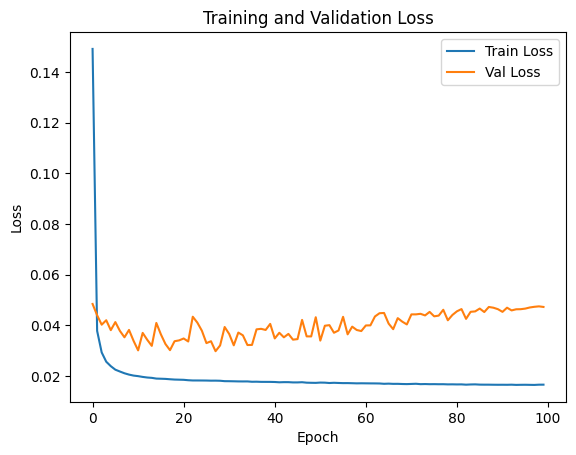

In [9]:
#100エポック回したときの残差の可視化
plt.plot(loss_train, label='Train Loss')
plt.plot(loss_val, label='Val Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [10]:
img = diffusion.inverse(model, 1)

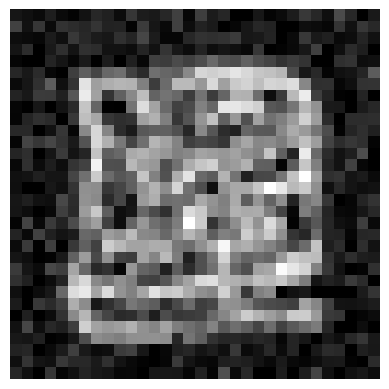

In [11]:
#生成した画像の表示
plt.imshow(img, cmap='gray', vmin=-1, vmax=1)
plt.axis('off')
plt.show()

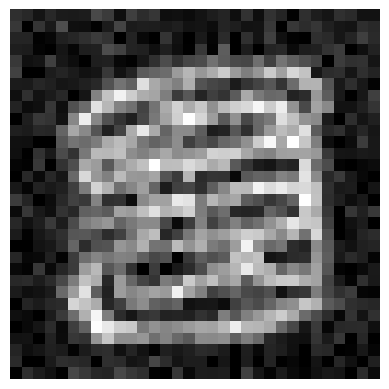

In [12]:
img = diffusion.inverse(model, 1)
#表示
plt.imshow(img, cmap='gray', vmin=-1, vmax=1)
plt.axis('off')
plt.show()

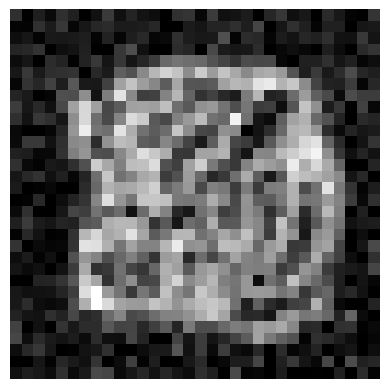

In [13]:
img = diffusion.inverse(model, 1)
#表示
plt.imshow(img, cmap='gray', vmin=-1, vmax=1)
plt.axis('off')
plt.show()